# Distribution Plots

Next, we’ll explore Seaborn, a statistical visualization library that integrates seamlessly with Pandas DataFrames. We’ll look at several types of plots that help visualize the distribution of a dataset, including:

- histplot
- jointplot
- pairplot
- rugplot
- kdeplot (theoretical)

In [1]:
# %pip install seaborn   # if you don't have seaborn installed
import seaborn as sns
# %matplotlib inline

## Data

Seaborn comes with built-in data sets. We did iris and tips already. Now tips again.

In [2]:
### Load the seaborn example tips dataset

tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [4]:
### people mostly do this one. I like tip better because of shape.

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
tips.info()     ### check data types
                ### tips.info is like tip 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


## histplot

The distplot shows the distribution of a **univariate** set of observations.

<Axes: xlabel='total_bill', ylabel='Count'>

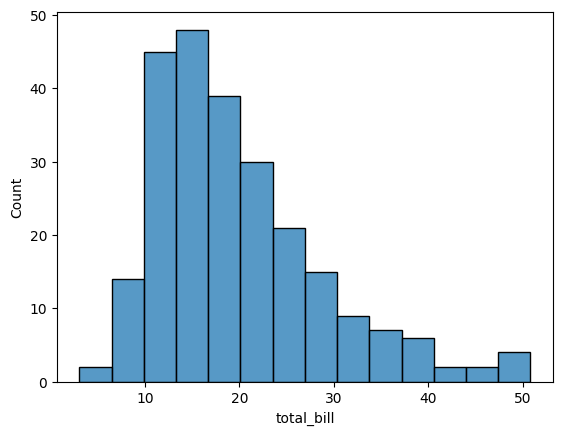

In [6]:
sns.histplot(tips['total_bill'])

Changing the `bin` number gives you control over the data intervals to display:

<Axes: xlabel='total_bill', ylabel='Count'>

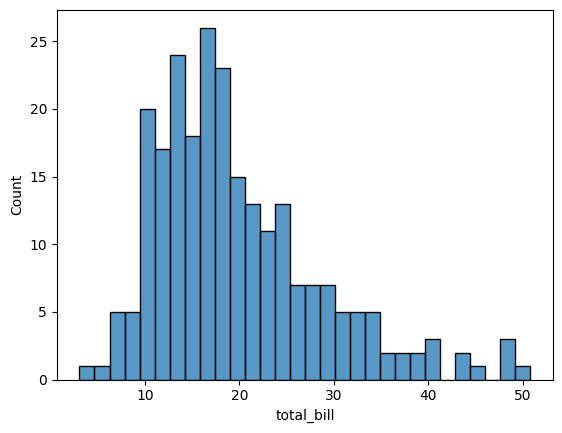

In [7]:
sns.histplot(tips['total_bill'], bins=30)

To control the size of the plot, use `figsize` in Matplotlib's `plt.subplots`:

```
import matplotlib.pyplot as plt
fig, axes = plt.subplots(figsize=(5, 3))            ### width: 5, height: 3
sns.histplot(tips['total_bill'], bins=30, ax=axes)  ### specify ax=axes to plot on the given axes
```

<Axes: xlabel='total_bill', ylabel='Count'>

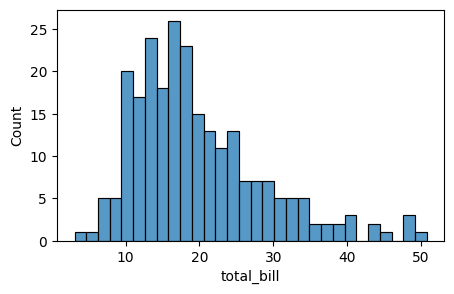

In [13]:
### figsize!!!

import matplotlib.pyplot as plt

fig, axes = plt.subplots(figsize=(5, 3))            ### width: 5, height: 3 ==> axes ==> ax
sns.histplot(tips['total_bill'], bins=30, ax=axes)  ### specify ax=axes to plot on the given axes

## jointplot

`jointplot()` allows you to match up two `histplots` for bivariate data. You can choose the **kind** parameter to compare with: 
* “scatter” 
* “reg” 
* “resid” 
* “kde” 
* “hex”

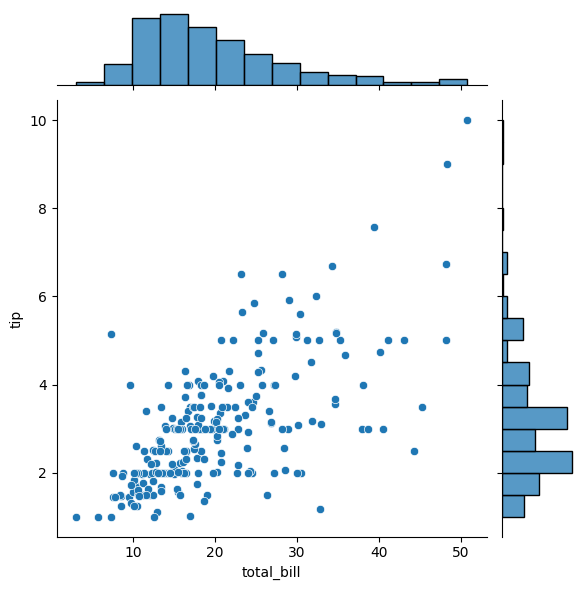

In [14]:
### change the kind here to play with it

sns.jointplot(x='total_bill', y='tip', data=tips, kind='scatter')

Choose `kind='hex'` to see the difference:

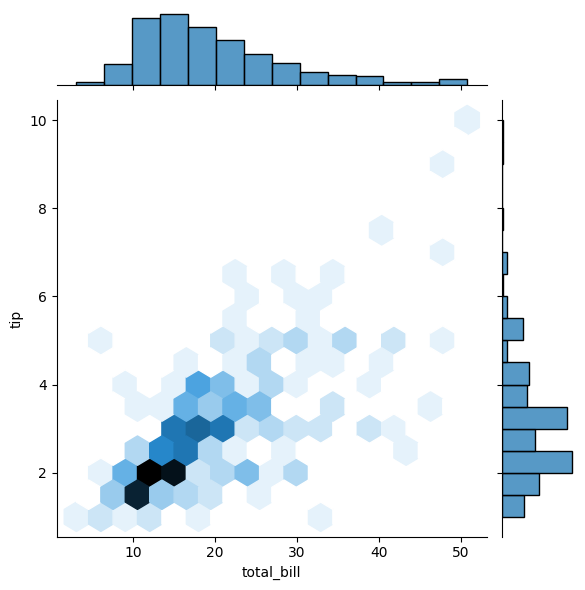

In [43]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='hex')

Regression plot gives you the regression information about the two numerical columns. Note that you have the distribution of x and y.

In [16]:
# tips.index.dtype

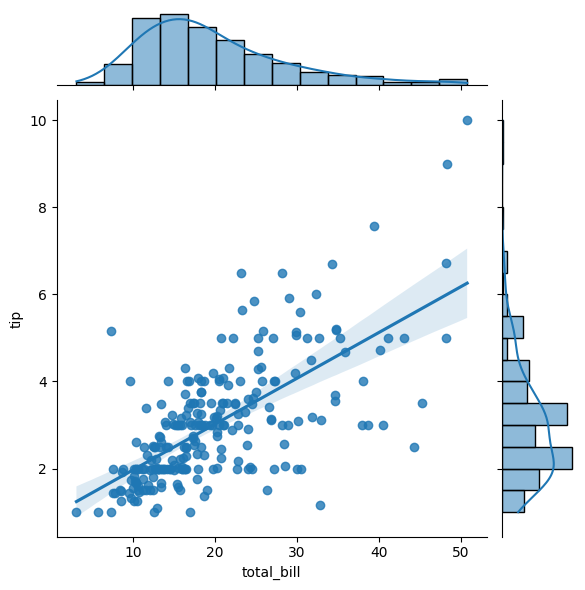

In [17]:
sns.jointplot(x='total_bill', y='tip', data=tips, kind='reg')

## pairplot

`pairplot` will plot pairwise relationships across an entire DataFrame (for the numerical columns). 

Seaborn’s `pairplot` visualizes pairwise relationships among all numerical columns in a DataFrame by drawing a grid of scatterplots (off-diagonals) and 1D distributions on the diagonals, letting you spot trends, clusters, and outliers at a glance. 

The color `hue` argument for categorical columns add color by a categorical variable.

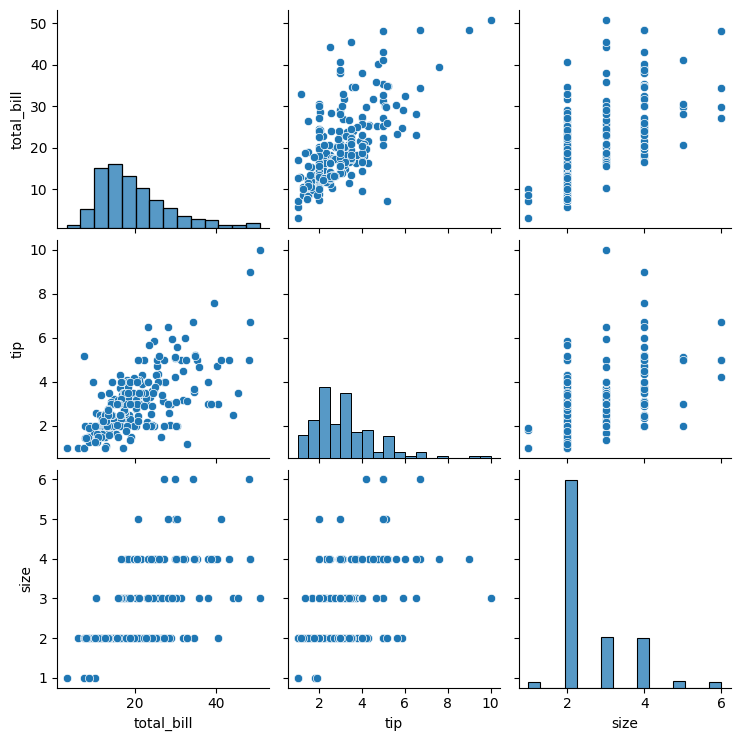

In [18]:
sns.pairplot(tips)

Adding a `hue=` argument takes a categorical variable to color by group, letting you compare groups in the same plot.

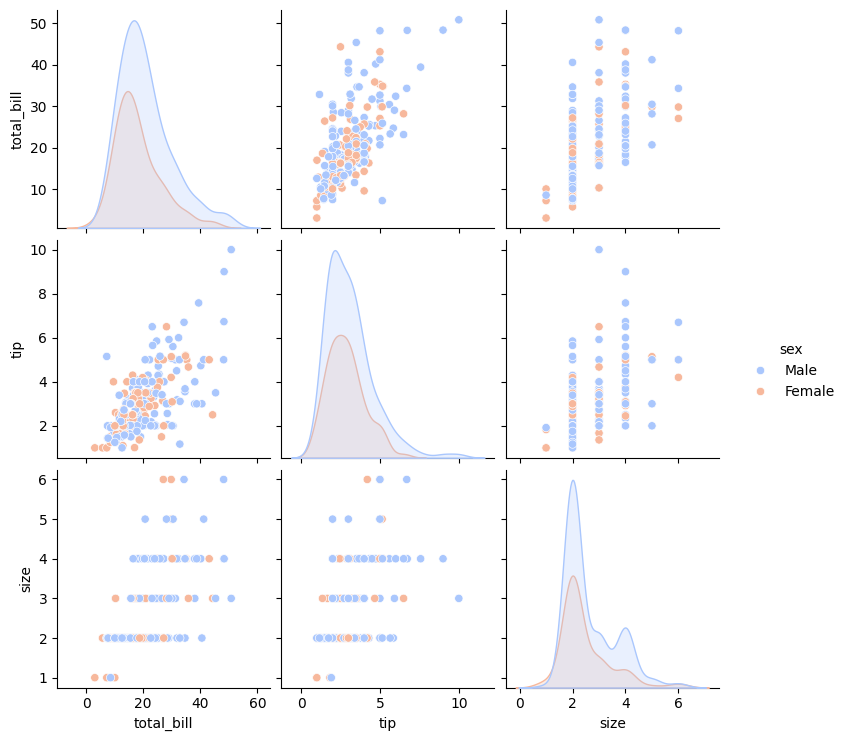

In [30]:
sns.pairplot(tips, hue='sex', palette='coolwarm')

## rugplot

`rugplot` draws a dash mark for every point on a univariate distribution, which are the building block of a KDE plot:

<Axes: xlabel='total_bill'>

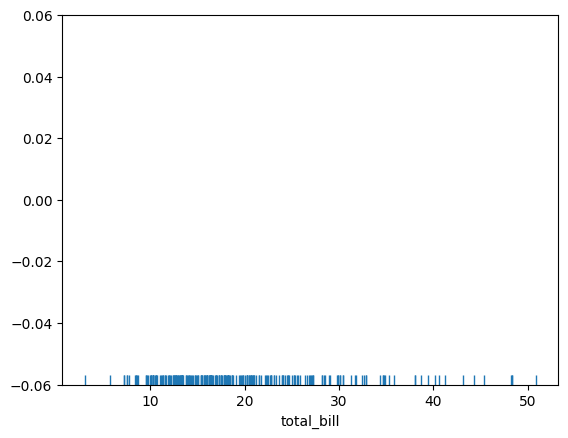

In [31]:
sns.rugplot(tips['total_bill'])

## kdeplot

kdeplots are [Kernel Density Estimation plots](http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth). These KDE plots replace every single observation with a Gaussian (Normal) distribution centered around that value. For example:

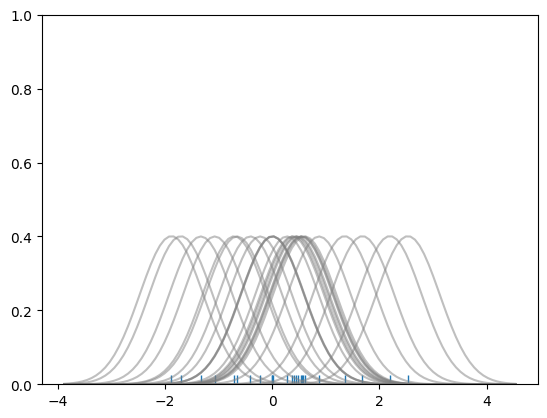

In [41]:
### don't worry about understanding this code!
### it's just for the diagram below

import numpy as np
import matplotlib.pyplot as plt
# %pip install scipy
from scipy import stats


dataset = np.random.randn(25)     ### create dataset
sns.rugplot(dataset)              ### create another rugplot

x_min = dataset.min() - 2         ### set up the x-axis for the plot
x_max = dataset.max() + 2         ### to give space to the plot
x_axis = np.linspace(x_min, x_max, 100)    ### 100 equally spaced points from x_min to x_max
plt.ylim(0,1)

### set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'

bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2

kernel_list = []                            ### create an empty kernel list
for data_point in dataset:                  ### plot each basis function
    kernel = stats.norm(data_point, bandwidth).pdf(x_axis)  ### create a kernel for each point 
    # kernel_list.append(kernel)              ### append to list
  
    kernel = kernel / kernel.max()          ### scale for plotting
    kernel = kernel * .4                    ### scale for plotting
    plt.plot(x_axis, kernel, color='grey', alpha=0.5)   ### create a bump


Text(0.5, 0.98, 'Sum of the Basis Functions')

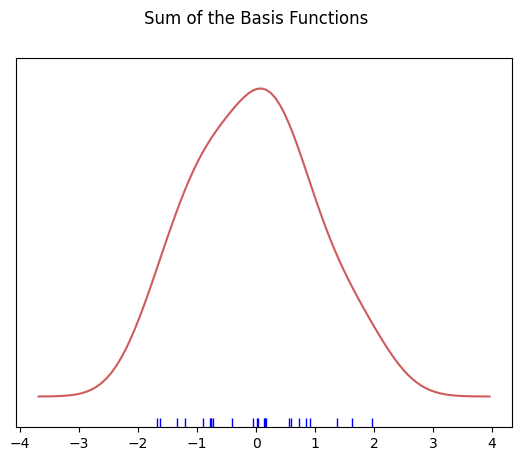

In [34]:
### to get the KDE plot we can sum these basis functions.
### plot the sum of the basis function

import numpy as np
sum_of_kde = np.sum(kernel_list, axis=0)
fig = plt.plot(x_axis,sum_of_kde,color='indianred')  ### plot figure
sns.rugplot(dataset, c ='b')                         ### add the initial rugplot
plt.yticks([])                                       ### get rid of y-tick marks
plt.suptitle("Sum of the Basis Functions")           ### set title

So with our tips dataset:

<Axes: xlabel='total_bill', ylabel='Density'>

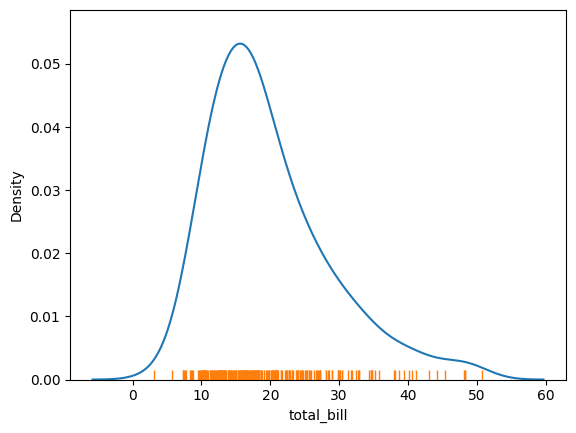

In [64]:
sns.kdeplot(tips['total_bill'])
sns.rugplot(tips['total_bill'])

<Axes: xlabel='tip', ylabel='Density'>

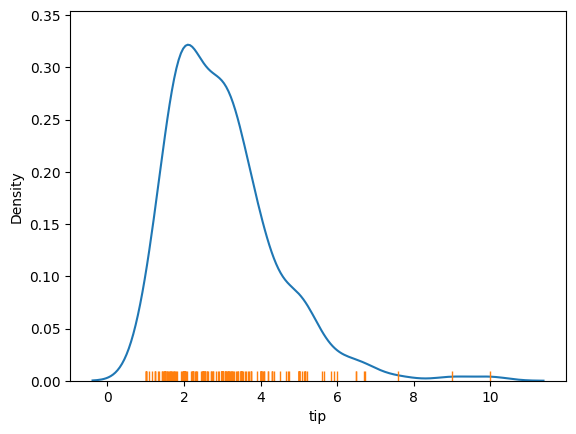

In [35]:
sns.kdeplot(tips['tip'])
sns.rugplot(tips['tip'])